# Introduction to Convolutional Neural Networks - Image analysis

## Overview

This kernel is aimed at giving a simple understanding of a Convolutional Neural Network (CNN). This will be achieved in the following order:

- Understanding the operation of convolution
- A short look back Neural Networks
- Data preprocessing
- Understanding the Convolutional Neural Network used
- Understanding Optimizers
- Understanding ImageDataGenerator
- Making the predictions and calculating the accuracy

## What is Convolution?

<b>Definition:</b>
   - In mathematics, convolution is a mathematical operation between two functions (f and g) to produce a third function that expresses how the shape of one is modified by the other.

<b>Utility:</b>
   - Convolution is used in several areas such as probability, statistics, computer vision, natural language processing, image and signal processing, engineering, and differential equations.


## What are Artificial Neural Networks?

<b>Definition: </b>
   - Artificial neural networks (ANN) or connectionist systems are computing systems vaguely inspired by the biological neural networks that constitute animal brains. Such systems "learn" to perform tasks by considering examples, generally without being programmed with any task-specific rules.
   - An ANN is a collection of smaller processing units called the artificial neurons which loosely resemble the biological neuron.
   - A collection of interconnected circuits make a network. </b>

## What are Convolutional Neural Networks

<b>Definition:</b>
   - In deep learning, a convolutional neural network (CNN, or ConvNet) is a class of artificial neural network (ANN), most commonly applied to analyze visual imagery.
   - CNNs were inspired by biological processes in that the connectivity pattern between neurons resembles the organization of the animal visual cortex.
   - A CNN architecture is formed by a stack of distinct layers that transform the input volume into an output volume through a differentiable function. A few distinct types of layers are commonly used.
   
<b>Convolutional layer:</b>
   - The convolutional layer is the core building block of a CNN. The layer's parameters consist of a set of learnable filters (or kernels), which have a small receptive field, but extend through the full depth of the input volume.
   - During the forward pass, each filter is convolved across the width and height of the input volume, computing the dot product between the filter entries and the input, producing a 2-dimensional activation map of that filter. As a result, the network learns filters that activate when it detects some specific type of feature at some spatial position in the input.
      
      <img src="https://miro.medium.com/max/1400/1*Fw-ehcNBR9byHtho-Rxbtw.gif" width="500" height="340">
      
<b>Pooling Layer</b>
   - There are several non-linear functions to implement pooling, where max pooling is the most common.
   - It partitions the input image into a set of rectangles and, for each such sub-region, outputs the maximum.
   
   <img src="https://nico-curti.github.io/NumPyNet/NumPyNet/images/maxpool.gif" width="500" height="340">

In [ ]:
import torch
from torch import nn,optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

MNIST Dataset:
  - handwritten digits
  - classification
  
https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST

In [1]:
import random
import matplotlib.pyplot as plt
from torchvision import datasets

raw_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

raw_test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:07<00:00, 1.28MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 88.4kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 507kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.92MB/s]


In [2]:
raw_train_dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

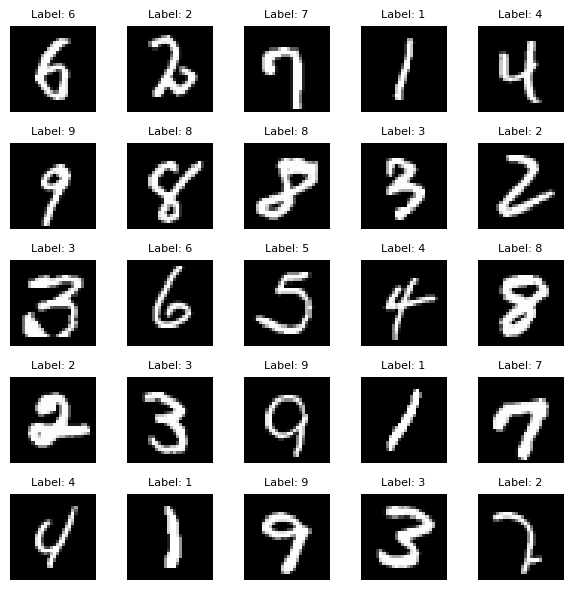

In [3]:
def show_random_raw_mnist_images(dataset, n=25):
    indices = random.sample(range(len(dataset)), n)

    rows = int(n ** 0.5)
    cols = rows

    if rows * cols < n:
        cols += 1

    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    axes = axes.flatten()

    for ax, idx in zip(axes, indices):
        image, label = dataset[idx]

        ax.imshow(image, cmap="gray")
        ax.set_title(f"Label: {label}", fontsize=8)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_raw_mnist_images(raw_train_dataset, n=25)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

NameError: name 'transforms' is not defined

In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [11]:
device = 'cpu:0'
LR = 1e-3

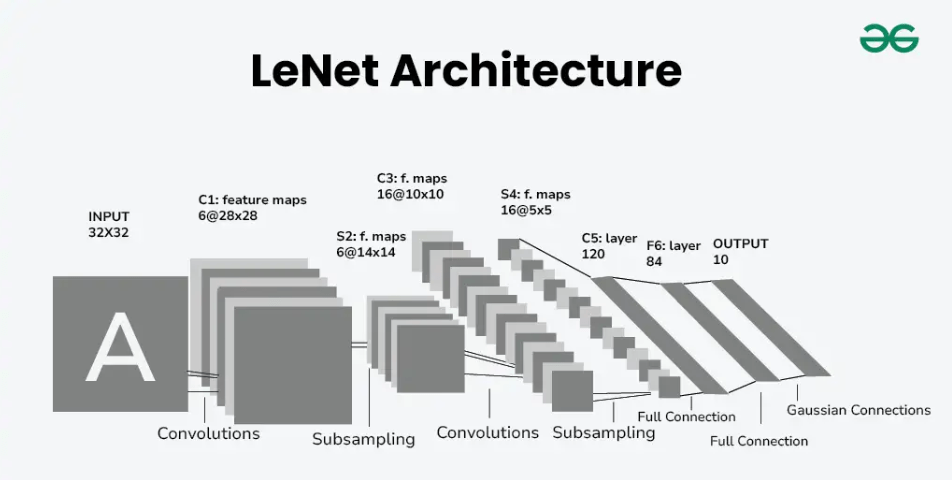

In [12]:
models = {
    "MLP": nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 256),
        nn.ReLU(),
        nn.Linear(256, 16),
        nn.ReLU(),
        nn.Linear(16, 10),
    ),

    "LeNet": nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(6, 16, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Flatten(),
        nn.Linear(16 * 4 * 4, 120),
        nn.ReLU(),
        nn.Linear(120, 84),
        nn.ReLU(),
        nn.Linear(84, 10),
    ),
}

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, test_loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_accuracy = correct / total

    return test_loss, test_accuracy


def train_model(model, model_name, num_epochs):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    print(f"\nTraining {model_name}")
    print("-" * 40)

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Test Loss: {test_loss:.4f} "
            f"Test Acc: {test_acc:.4f}"
        )

    return history

In [14]:
histories = {
    key: train_model(models[key],key,num_epochs=5)
    for key in models
}


Training MLP
----------------------------------------
Epoch [1/5] Train Loss: 0.2798 Train Acc: 0.9161 Test Loss: 0.1313 Test Acc: 0.9616
Epoch [2/5] Train Loss: 0.1079 Train Acc: 0.9669 Test Loss: 0.0905 Test Acc: 0.9717
Epoch [3/5] Train Loss: 0.0739 Train Acc: 0.9776 Test Loss: 0.0859 Test Acc: 0.9731
Epoch [4/5] Train Loss: 0.0562 Train Acc: 0.9822 Test Loss: 0.0821 Test Acc: 0.9767
Epoch [5/5] Train Loss: 0.0448 Train Acc: 0.9852 Test Loss: 0.1019 Test Acc: 0.9693

Training LeNet
----------------------------------------
Epoch [1/5] Train Loss: 0.2349 Train Acc: 0.9287 Test Loss: 0.0696 Test Acc: 0.9783
Epoch [2/5] Train Loss: 0.0725 Train Acc: 0.9774 Test Loss: 0.0541 Test Acc: 0.9829
Epoch [3/5] Train Loss: 0.0510 Train Acc: 0.9844 Test Loss: 0.0507 Test Acc: 0.9826
Epoch [4/5] Train Loss: 0.0396 Train Acc: 0.9872 Test Loss: 0.0374 Test Acc: 0.9877
Epoch [5/5] Train Loss: 0.0309 Train Acc: 0.9898 Test Loss: 0.0344 Test Acc: 0.9887


In [15]:
import matplotlib.pyplot as plt

def plot_all_histories(histories):
    metrics = {
        "train_loss": "Training Loss",
        "test_loss": "Test Loss",
        "train_acc": "Training Accuracy",
        "test_acc": "Test Accuracy"
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.flatten()

    for ax, (metric_name, title) in zip(axes, metrics.items()):
        for model_name, history in histories.items():
            epochs = range(1, len(history[metric_name]) + 1)

            ax.plot(
                epochs,
                history[metric_name],
                marker="o",
                label=model_name
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

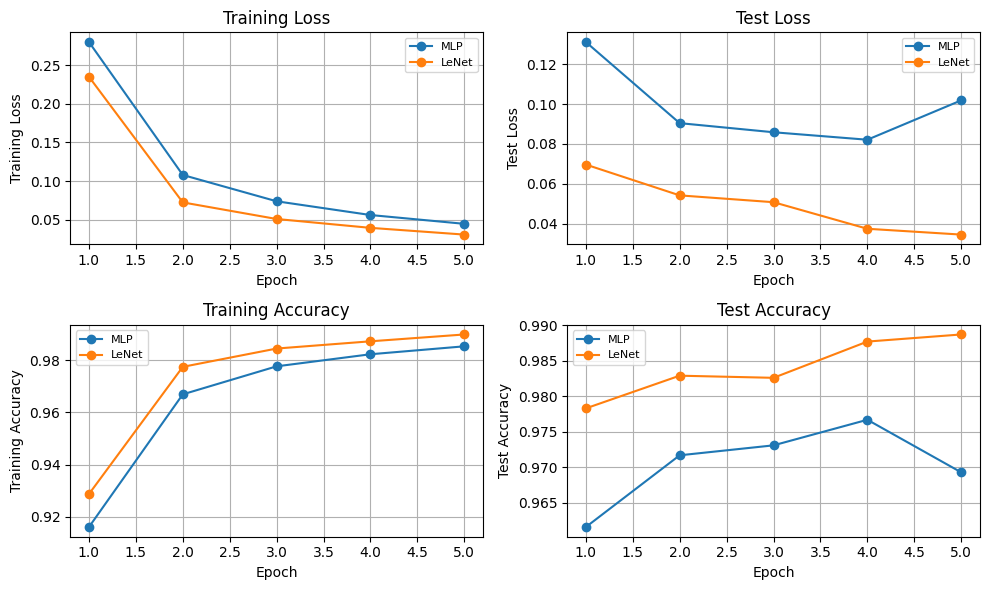

In [16]:
plot_all_histories(histories)

In [17]:
def num_params(model):
  return sum(y.numel() for y in model.parameters())

In [18]:
{key:num_params(model) for key,model in models.items()}

{'MLP': 205242, 'LeNet': 44426}

#### Visualizing the mistakes of the models

In [24]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices_side_by_side(
    trained_models,
    test_loader,
    device,
    normalize=None,
    class_names=None
):
    if class_names is None:
        class_names = [str(i) for i in range(10)]

    num_models = len(trained_models)

    fig, axes = plt.subplots(
        1,
        num_models,
        figsize=(5 * num_models, 4)
    )

    if num_models == 1:
        axes = [axes]

    for ax, (model_name, model) in zip(axes, trained_models.items()):
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)

                outputs = model(images)
                preds = outputs.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        cm = confusion_matrix(
            all_labels,
            all_preds,
            normalize=normalize
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )

        disp.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format=".2f" if normalize else "d"
        )

        ax.set_title(f"{model_name}")
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

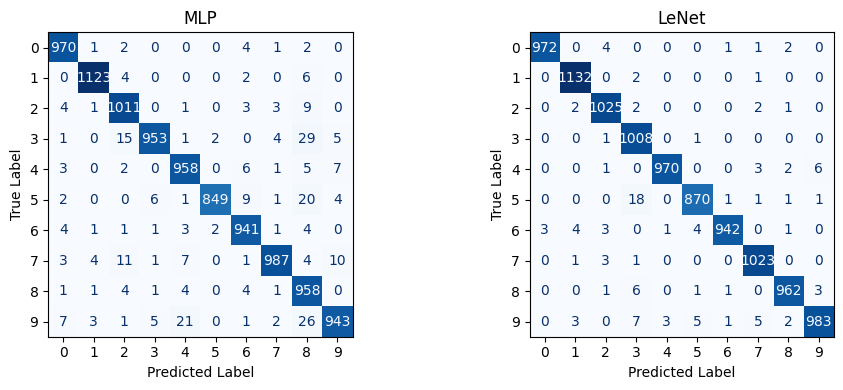

In [26]:
plot_confusion_matrices_side_by_side(
    trained_models=models,
    test_loader=test_loader,
    device=device
)

### Other applications of CNNs

- Classification
- Search (in the section below)
- Out-of-domain classification (in the section below)

In [1]:
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

### Download the Animal Image Dataset

https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals?resource=download

In [2]:
DATA_DIR = Path("./data/animals/animals/")

BATCH_SIZE = 64
NUM_WORKERS = 4

In [3]:
device = 'cpu:0'

In [4]:
weights = MobileNet_V3_Large_Weights.IMAGENET1K_V2
transform = weights.transforms()

base_model = mobilenet_v3_large(weights=weights)
base_model.eval()
base_model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

In [5]:
class MobileNetV3Embedding(nn.Module):
    def __init__(self, mobilenet):
        super().__init__()
        self.features = mobilenet.features
        self.avgpool = mobilenet.avgpool
        self.classification = nn.Linear(960, 90)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.classification(x)
        return x

In [6]:
embedding_model = MobileNetV3Embedding(base_model)
embedding_model.eval()
embedding_model.to(device)

MobileNetV3Embedding(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16,

In [7]:
for p in embedding_model.parameters():
    p.requires_grad = False
for p in embedding_model.classification.parameters():
    p.requires_grad = True

In [43]:
dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transform,
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

image_paths = [path for path, label in dataset.samples]
labels = [label for path, label in dataset.samples]
class_names = dataset.classes

print("Number of images:", len(dataset))
print("Number of classes:", len(class_names))
print("Example classes:", class_names[:10])

Number of images: 5400
Number of classes: 90
Example classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat']


In [8]:

import torch
from torch.utils.data import Dataset, random_split

dataset = datasets.ImageFolder(
    root=DATA_DIR,
    transform=transform,
)
total_size = len(dataset)
train_size = int(0.8 * total_size)       
test_size = total_size - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [12]:
next(iter(train_loader))[0].shape

torch.Size([64, 3, 224, 224])

In [17]:
import torch.nn.functional as F

def extract_embeddings(dataloader, model, device):
    all_embeddings = []
    all_labels = []
    
    model.eval() 
    
    with torch.no_grad():
        for images, batch_labels in dataloader:
            images = images.to(device)
            
            batch_embeddings = model(images)
            batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)
            
            all_embeddings.append(batch_embeddings.cpu())
            all_labels.append(batch_labels)
            
    return torch.cat(all_embeddings, dim=0), torch.cat(all_labels, dim=0)


print("train")
train_embeddings, train_labels = extract_embeddings(train_loader, embedding_model, device)

print("test")
test_embeddings, test_labels = extract_embeddings(test_loader, embedding_model, device)

print(f"Dimensiuni Train: {train_embeddings.shape}")
print(f"Dimensiuni Test:  {test_embeddings.shape}")

Extragem amprentele pentru baza de date (Train)...
Extragem amprentele pentru pozele noi (Test)...
Dimensiuni Train: torch.Size([4320, 90])
Dimensiuni Test:  torch.Size([1080, 90])


In [18]:
def search_similar(query_image_path, db_embeddings, db_labels, top_k=10):
    image = Image.open(query_image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        query_emb = embedding_model(image)
        query_emb = F.normalize(query_emb, dim=1).cpu()

    similarities = query_emb @ db_embeddings.T

    scores, indices = torch.topk(similarities.squeeze(0), top_k)

    results = []

    for score, idx in zip(scores, indices):
        idx = idx.item()
        label_idx = db_labels[idx].item()
        
        original_idx = train_dataset.indices[idx]
        
        original_path = dataset.samples[original_idx][0]

        results.append({
            "path": original_path,
            "class": dataset.classes[label_idx],
            "score": score.item()
        })

    return results

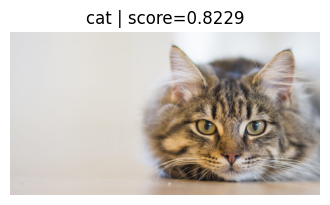

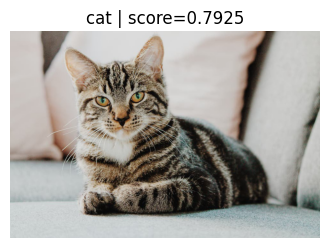

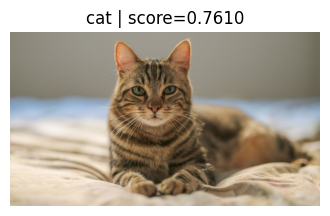

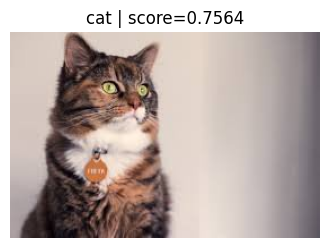

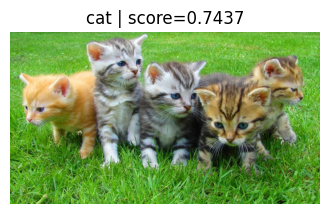

In [19]:
import matplotlib.pyplot as plt

results = search_similar("./cat.jpg", db_embeddings=train_embeddings, db_labels=train_labels, top_k=5)

for r in results:
    img = Image.open(r["path"]).convert("RGB")

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"{r['class']} | score={r['score']:.4f}")
    plt.axis("off")
    plt.show()

In [ ]:
----------------

In [11]:
all_embeddings = []
all_labels = []

with torch.no_grad():
    for images, batch_labels in loader:
        images = images.to(device)

        batch_embeddings = embedding_model(images)
        batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)

        all_embeddings.append(batch_embeddings.cpu())
        all_labels.append(batch_labels)

all_embeddings = torch.cat(all_embeddings, dim=0)
all_labels = torch.cat(all_labels, dim=0)

print("Embeddings shape:", all_embeddings.shape)

NameError: name 'loader' is not defined

In [25]:
def search_similar(query_image_path, top_k=10):
    image = Image.open(query_image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        query_emb = embedding_model(image)
        query_emb = F.normalize(query_emb, dim=1).cpu()

    similarities = query_emb @ all_embeddings.T

    scores, indices = torch.topk(similarities.squeeze(0), top_k)

    results = []

    for score, idx in zip(scores, indices):
        idx = idx.item()
        label_idx = all_labels[idx].item()

        results.append({
            "path": image_paths[idx],
            "class": class_names[label_idx],
            "score": score.item()
        })

    return results

In [ ]:
results = search_similar("./cat.jpg", top_k=10)

for r in results:
    print(f"{r['score']:.4f} | {r['class']} | {r['path']}")

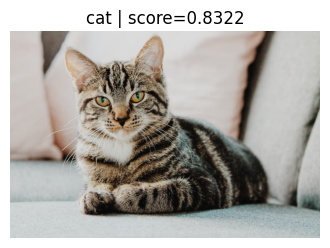

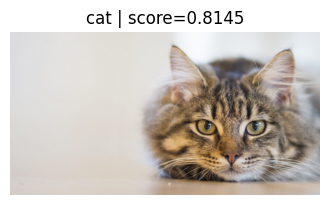

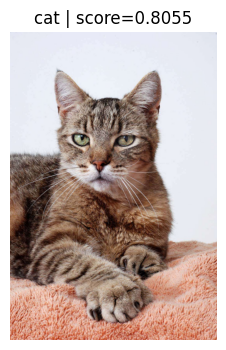

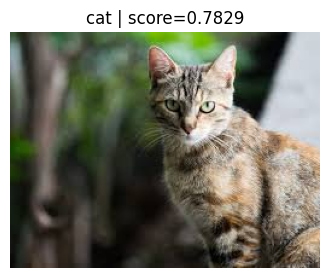

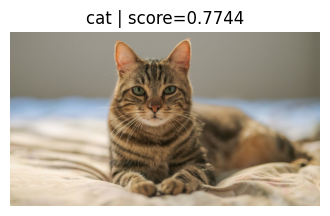

In [27]:
import matplotlib.pyplot as plt

results = search_similar("./cat.jpg", top_k=5)

for r in results:
    img = Image.open(r["path"]).convert("RGB")

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"{r['class']} | score={r['score']:.4f}")
    plt.axis("off")
    plt.show()